Đang sử dụng cấu hình tối ưu: cuda
-> Tên GPU: Tesla T4

--- BẤT ĐẦU VÒNG KHẢO SÁT 5-FOLD CROSS VALIDATION TỐI ƯU ---

--> Đang tính toán kiểm tra chéo cho mô hình: LSTM...
    -> Kết quả Mean F1-Score của LSTM: 83.63%

--> Đang tính toán kiểm tra chéo cho mô hình: GRU...
    -> Kết quả Mean F1-Score của GRU: 83.13%

--> Đang tính toán kiểm tra chéo cho mô hình: CNN-1D...
    -> Kết quả Mean F1-Score của CNN-1D: 72.44%

--> Đang tính toán kiểm tra chéo cho mô hình: BiGRU-Attention...
    -> Kết quả Mean F1-Score của BiGRU-Attention: 86.02%

================ BẢNG KẾT QUẢ ĐÁNH GIÁ 5-FOLD TOÀN DIỆN ================
--> MODEL BiGRU-Attention : Mean F1 = 86.02% | Mean Recall = 90.78% | Mean Acc = 92.80%
--> MODEL LSTM            : Mean F1 = 83.63% | Mean Recall = 93.34% | Mean Acc = 91.07%
--> MODEL GRU             : Mean F1 = 83.13% | Mean Recall = 92.49% | Mean Acc = 90.80%
--> MODEL CNN-1D          : Mean F1 = 72.44% | Mean Recall = 88.67% | Mean Acc = 83.48%

[Thành công] Đã lưu bản sao

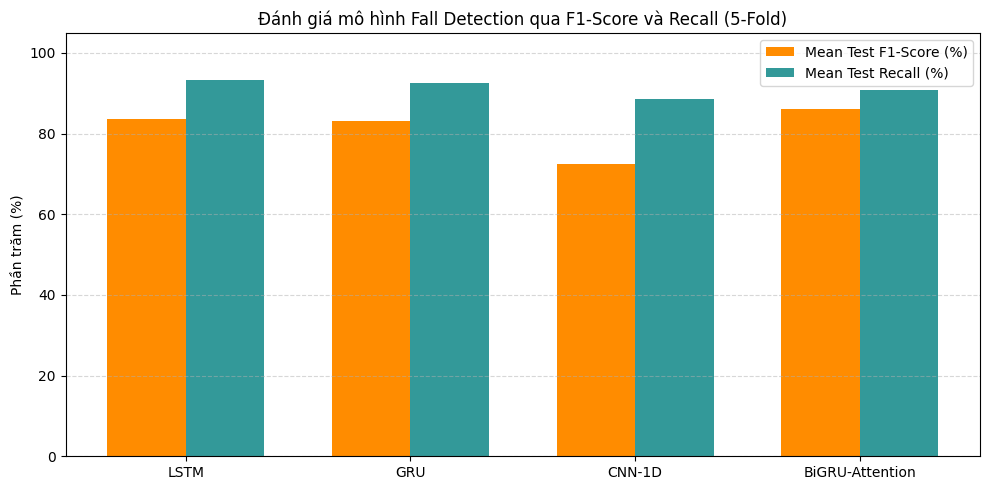

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as metrics
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# Ép kiểu đồ họa hiển thị inline mượt mà trên môi trường Notebook
%matplotlib inline

# Kiểm tra và cấu hình thiết bị chạy (Ưu tiên GPU T4 trên Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng cấu hình tối ưu: {device}")
if torch.cuda.is_available():
    print(f"-> Tên GPU: {torch.cuda.get_device_name(0)}")


# -------------------------------------------------------------
# 1. ĐỊNH NGHĨA HÀM FOCAL LOSS CHUẨN (CÂN BẰNG ĐỘNG THEO TARGET)
# -------------------------------------------------------------
class FocalLoss(nn.Module):

    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # Ưu tiên class 1 (Fall)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction="none"
        )
        pt = torch.exp(-BCE_loss)

        # Cải tiến: Nhân alpha động dựa trên giá trị của target thực tế
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        if self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


# -------------------------------------------------------------
# 2. DATASET NÂNG CAO (HẠ NHIỄU GIÚP GIỮ FORM CỦA SKELETON)
# -------------------------------------------------------------
class OptimizedSkeletonDataset(Dataset):

    def __init__(self, sequences, labels, max_len=16, is_train=False):
        self.sequences = []
        self.labels = []
        self.is_train = is_train
        self.max_len = max_len

        for idx, seq in enumerate(sequences):
            seq = np.array(seq)

            # Feature Engineering (Velocity & Acceleration)
            raw_flat = seq.reshape(seq.shape[0], -1)
            velocity = np.diff(raw_flat, axis=0, append=raw_flat[-1:])
            acceleration = np.diff(velocity, axis=0, append=velocity[-1:])
            enriched_seq = np.hstack((raw_flat, velocity, acceleration))

            if len(enriched_seq) >= self.max_len:
                seq_padded = enriched_seq[: self.max_len]
            else:
                padding = np.zeros((self.max_len - len(enriched_seq), 102))
                seq_padded = np.vstack((enriched_seq, padding))

            self.sequences.append(seq_padded)
            self.labels.append(labels[idx])

            # Augmentation có kiểm soát: Hạ noise xuống 0.005 để tránh hỏng pose
            if self.is_train and labels[idx] == 1:
                noise = np.random.normal(0, 0.005, seq_padded.shape)
                self.sequences.append(seq_padded + noise)
                self.labels.append(labels[idx])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])


# -------------------------------------------------------------
# 3. POOL MÔ HÌNH THỬ NGHIỆM (BỔ SUNG BIGRU + ATTENTION)
# -------------------------------------------------------------
class LSTMModel(nn.Module):

    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):

    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


class CNN1DModel(nn.Module):

    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.conv1 = nn.Conv1d(
            in_channels=input_size,
            out_channels=hidden_size,
            kernel_size=3,
            padding=1,
        )
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.relu(self.conv1(x))
        x = torch.flatten(self.pool(x), 1)
        return self.fc(x)


class BiGRUAttentionModel(nn.Module):

    def __init__(self, input_size=102, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True,
        )
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        attn_scores = self.attention(out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(out * attn_weights, dim=1)
        return self.fc(context)


# -------------------------------------------------------------
# 4. HÀM TRAIN & EVALUATE BATCH SIZE = 32
# -------------------------------------------------------------
def train_and_eval_deep_model(model_class, loaders, criterion):
    train_loader, test_loader = loaders
    model = model_class().to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=0.001, weight_decay=0.01
    )

    for epoch in range(40):
        model.train()
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(seqs), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(seqs)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    acc = metrics.accuracy_score(all_labels, all_preds)
    recall = metrics.recall_score(all_labels, all_preds, zero_division=0)
    f1 = metrics.f1_score(all_labels, all_preds, zero_division=0)

    return acc, recall, f1


# -------------------------------------------------------------
# 5. MAIN PIPELINE EXECUTION
# -------------------------------------------------------------
def main():
    # Cấu hình đường dẫn chạy trực tiếp trên môi trường gốc của Colab
    X_path = "./data_processed/imvia_sequences.npy"
    y_path = "./data_processed/imvia_labels.npy"

    if not os.path.exists(X_path) or not os.path.exists(y_path):
        raise FileNotFoundError(
            "Không tìm thấy dữ liệu! Hãy chắc chắn bạn đã tạo thư mục 'data_processed' và kéo thả các file .npy vào đó."
        )

    X = np.load(X_path, allow_pickle=True)
    y = np.load(y_path)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    deep_models_pool = {
        "LSTM": LSTMModel,
        "GRU": GRUModel,
        "CNN-1D": CNN1DModel,
        "BiGRU-Attention": BiGRUAttentionModel,
    }

    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    final_results = {}

    print("\n--- BẤT ĐẦU VÒNG KHẢO SÁT 5-FOLD CROSS VALIDATION TỐI ƯU ---")

    for name, model_class in deep_models_pool.items():
        fold_accs, fold_recalls, fold_f1s = [], [], []
        print(f"\n--> Đang tính toán kiểm tra chéo cho mô hình: {name}...")

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            train_dataset = OptimizedSkeletonDataset(
                X_train, y_train, max_len=16, is_train=True
            )
            test_dataset = OptimizedSkeletonDataset(
                X_test, y_test, max_len=16, is_train=False
            )

            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

            acc, rec, f1 = train_and_eval_deep_model(
                model_class, (train_loader, test_loader), criterion
            )
            fold_accs.append(acc)
            fold_recalls.append(rec)
            fold_f1s.append(f1)

        final_results[name] = {
            "Accuracy": np.mean(fold_accs) * 100,
            "Recall": np.mean(fold_recalls) * 100,
            "F1-Score": np.mean(fold_f1s) * 100,
        }
        print(
            f"    -> Kết quả Mean F1-Score của {name}: {final_results[name]['F1-Score']:.2f}%"
        )

    print(
        "\n================ BẢNG KẾT QUẢ ĐÁNH GIÁ 5-FOLD TOÀN DIỆN ================"
    )
    for model_name, metrics_dict in sorted(
        final_results.items(), key=lambda item: item[1]["F1-Score"], reverse=True
    ):
        print(
            f"--> MODEL {model_name.ljust(16)}: Mean F1 = {metrics_dict['F1-Score']:.2f}% | Mean Recall = {metrics_dict['Recall']:.2f}% | Mean Acc = {metrics_dict['Accuracy']:.2f}%"
        )
    print(
        "========================================================================="
    )

    # -------------------------------------------------------------
    # 6. XUẤT BIỂU ĐỒ SO SÁNH (HIỂN THỊ TRỰC TIẾP TRÊN COLAB CELL)
    # -------------------------------------------------------------
    model_labels = list(final_results.keys())
    mean_f1s = [final_results[m]["F1-Score"] for m in model_labels]
    mean_recalls = [final_results[m]["Recall"] for m in model_labels]

    x = np.arange(len(model_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        x - width / 2,
        mean_f1s,
        width,
        label="Mean Test F1-Score (%)",
        color="darkorange",
    )
    ax.bar(
        x + width / 2,
        mean_recalls,
        width,
        label="Mean Test Recall (%)",
        color="teal",
        alpha=0.8,
    )

    ax.set_ylabel("Phần trăm (%)")
    ax.set_title(
        "Đánh giá mô hình Fall Detection qua F1-Score và Recall (5-Fold)"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels)
    ax.set_ylim(0, 105)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

    # Lưu biểu đồ vào file tĩnh
    os.makedirs("./plots", exist_ok=True)
    plt.savefig("./plots/deep_learning_comparison.png", dpi=300)
    print(
        "\n[Thành công] Đã lưu bản sao biểu đồ tĩnh tại: './plots/deep_learning_comparison.png'"
    )

    # Hiển thị trực tiếp biểu đồ ngay trong dòng xuất lệnh của Colab
    plt.show()


if __name__ == "__main__":
    main()

In [6]:
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    recall_score, accuracy_score, f1_score,
    confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng cấu hình: {device}")

# =============================================================
# 1. FOCAL LOSS CHUẨN
# =============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        focal = alpha_t * (1 - pt) ** self.gamma * bce
        return focal.mean() if self.reduction == 'mean' else focal

# =============================================================
# 2. DATASET
# =============================================================
class OptimizedSkeletonDataset(Dataset):
    def __init__(self, sequences, labels, max_len=16, is_train=False):
        self.is_train = is_train
        self.max_len = max_len
        self.labels = np.array(labels, dtype=np.float32)
        self.sequences = []

        for seq in sequences:
            seq = np.array(seq, dtype=np.float32)
            raw_flat = seq.reshape(seq.shape[0], -1)

            T, F = raw_flat.shape
            if T >= max_len:
                padded_raw = raw_flat[:max_len]
            else:
                padding = np.tile(raw_flat[0], (max_len - T, 1))
                padded_raw = np.vstack((padding, raw_flat))

            velocity = np.diff(padded_raw, axis=0, append=padded_raw[-1:])
            acceleration = np.diff(velocity, axis=0, append=velocity[-1:])
            enriched = np.hstack((padded_raw, velocity, acceleration))

            self.sequences.append(enriched.astype(np.float32))

        self.sequences = np.array(self.sequences, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = self.sequences[idx].copy()
        if self.is_train and self.labels[idx] == 1 and random.random() < 0.5:
            seq = seq + np.random.normal(0, 0.02, seq.shape).astype(np.float32)
        return torch.tensor(seq), torch.tensor(self.labels[idx])

# =============================================================
# 3. MÔ HÌNH BiGRU-ATTENTION
# =============================================================
class BiGRUAttentionModel(nn.Module):
    def __init__(self, input_size=102, hidden_size=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        attn_scores = self.attention(out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(out * attn_weights, dim=1)
        return self.fc(context)

# =============================================================
# 4. ĐÁNH GIÁ
# =============================================================
def evaluate_model(model, dataloader, criterion, threshold=0.5):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for seqs, labels in dataloader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    avg_loss = total_loss / len(dataloader)

    return avg_loss, acc, rec, f1, all_labels, all_preds, all_probs

def find_optimal_threshold(all_labels, all_probs):
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    idx = np.argmax(tpr - fpr)
    return float(thresholds[idx])

# =============================================================
# 5. SỬA ĐỔI: GRID SEARCH THEO CHỈ SỐ F1-SCORE LÀM GỐC
# =============================================================
def run_grid_search(train_loader, val_loader, criterion, grid_space, probe_epochs=35):
    best_f1     = -1.0
    best_recall = -1.0
    best_config = None

    print("\n==== GIAI ĐOẠN 1: GRID SEARCH (BiGRU-Attention) ====")
    for h_size in grid_space['hidden_size']:
        for n_layers in grid_space['num_layers']:
            for lr_rate in grid_space['lr']:
                config = {'hidden_size': h_size, 'num_layers': n_layers, 'lr': lr_rate}
                set_seed(42)
                model = BiGRUAttentionModel(hidden_size=h_size, num_layers=n_layers).to(device)
                optimizer = torch.optim.AdamW(model.parameters(), lr=lr_rate, weight_decay=0.01)

                best_probe_f1 = -1.0
                best_probe_state = None
                no_improve = 0
                patience = 7

                for epoch in range(probe_epochs):
                    model.train()
                    for seqs, labels in train_loader:
                        seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
                        optimizer.zero_grad()
                        criterion(model(seqs), labels).backward()
                        optimizer.step()

                    _, _, val_rec, val_f1, _, _, _ = evaluate_model(model, val_loader, criterion)

                    # SỬA LỖI: Tối ưu trực tiếp theo F1-Score ở bước probe ngắn
                    if val_f1 > best_probe_f1:
                        best_probe_f1 = val_f1
                        best_probe_state = copy.deepcopy(model.state_dict())
                        no_improve = 0
                    else:
                        no_improve += 1
                    if no_improve >= patience:
                        break

                if best_probe_state is not None:
                    model.load_state_dict(best_probe_state)

                _, _, val_rec, val_f1, _, _, _ = evaluate_model(model, val_loader, criterion)
                print(f"  H={h_size} L={n_layers} LR={lr_rate} "
                      f"| Val F1: {val_f1*100:.1f}% | Val Recall: {val_rec*100:.1f}%")

                # SỬA LỖI: Quyết định chọn cấu hình dựa trên F1-Score trước, Recall sau
                if val_f1 > best_f1 or (val_f1 == best_f1 and val_rec > best_recall):
                    best_f1     = val_f1
                    best_recall = val_rec
                    best_config = config

    print(f"\n[*] Config tối ưu chọn theo F1: {best_config}")
    return best_config

# =============================================================
# 6. SỬA ĐỔI: HUẤN LUYỆN CHI TIẾT VÀ CHỐNG OVERFITTING THEO F1
# =============================================================
def train_final_model(train_loader, val_loader, best_config, criterion, epochs=50):
    model = BiGRUAttentionModel(
        hidden_size=best_config['hidden_size'],
        num_layers=best_config['num_layers']
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=best_config['lr'], weight_decay=0.01
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_f1_score   = -1.0
    best_model_state = None
    patience        = 10  # Siết chặt lại patience để chặn đứng Overfitting sớm hơn
    no_improve      = 0

    print("\n==== GIAI ĐOẠN 2: HUẤN LUYỆN CHI TIẾT (BiGRU-Attention) ====")

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(seqs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            preds          = (torch.sigmoid(outputs) >= 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc  = train_correct / train_total

        epoch_val_loss, epoch_val_acc, epoch_val_rec, epoch_val_f1, _, _, _ = \
            evaluate_model(model, val_loader, criterion)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        # SỬA LỖI: Theo dõi Scheduler dựa trên Val F1 thực tế
        scheduler.step(epoch_val_f1)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"TrainLoss: {epoch_train_loss:.4f} TrainAcc: {epoch_train_acc*100:.1f}% | "
              f"ValLoss: {epoch_val_loss:.4f} ValAcc: {epoch_val_acc*100:.1f}% "
              f"ValF1: {epoch_val_f1*100:.1f}% ValRecall: {epoch_val_rec*100:.1f}%")

        # SỬA LỖI: Early Stopping lưu model tại đỉnh cao nhất của F1-Score
        if epoch_val_f1 > best_f1_score:
            best_f1_score    = epoch_val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            no_improve       = 0
            print(f"  ==> Cải thiện! Toàn diện Val F1={best_f1_score*100:.1f}% — đã lưu trạng thái model.")
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"  [Early Stop] Không cải thiện F1 sau {patience} epoch. Ngắt để chống Overfit.")
            break

    if best_model_state is None:
        best_model_state = copy.deepcopy(model.state_dict())

    return model, best_model_state, history

# =============================================================
# 7. MAIN PIPELINE
# =============================================================
def main():
    X = np.load('./data_processed/imvia_sequences.npy', allow_pickle=True)
    y = np.load('./data_processed/imvia_labels.npy')

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
    )

    def seed_worker(worker_id):
        np.random.seed(42 + worker_id)
        random.seed(42 + worker_id)

    g = torch.Generator()
    g.manual_seed(42)

    train_loader = DataLoader(
        OptimizedSkeletonDataset(X_train, y_train, max_len=16, is_train=True),
        batch_size=8, shuffle=True,
        worker_init_fn=seed_worker, generator=g
    )
    val_loader = DataLoader(
        OptimizedSkeletonDataset(X_val, y_val, max_len=16),
        batch_size=8, shuffle=False
    )
    test_loader = DataLoader(
        OptimizedSkeletonDataset(X_test, y_test, max_len=16),
        batch_size=8, shuffle=False
    )

    criterion = FocalLoss(alpha=0.75, gamma=2.0)

    grid_space = {
        'hidden_size': [32, 64],
        'num_layers':  [1, 2],
        'lr':          [0.001, 0.005]
    }

    best_config = run_grid_search(train_loader, val_loader, criterion, grid_space, probe_epochs=35)

    final_model, best_model_state, history = train_final_model(
        train_loader, val_loader, best_config, criterion, epochs=50
    )

    final_model.load_state_dict(best_model_state)
    _, _, _, _, val_true, _, val_probs = evaluate_model(final_model, val_loader, criterion)
    optimal_threshold = find_optimal_threshold(val_true, val_probs)
    print(f"\n[*] Threshold tối ưu (Youden Index trên Val): {optimal_threshold:.4f}")

    test_loss, test_acc, test_rec, test_f1, true_labels, pred_labels, _ = \
        evaluate_model(final_model, test_loader, criterion, threshold=optimal_threshold)

    print("\n==== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST (BiGRU-ATTENTION OPTIMIZED) ====")
    print(f"Threshold sử dụng         : {optimal_threshold:.4f}")
    print(f"Accuracy                  : {test_acc*100:.2f}%")
    print(f"Recall (nhạy ca té ngã)   : {test_rec*100:.2f}%")
    print(f"F1-Score                  : {test_f1*100:.2f}%")
    print("=" * 60)

    os.makedirs("./models", exist_ok=True)
    np.save('./models/best_bigru_attn_config.npy', {**best_config, 'threshold': optimal_threshold})
    torch.save(best_model_state, './models/best_bigru_attn_fall_model.pth')
    print("[OK] Đã lưu model tại './models/best_bigru_attn_fall_model.pth'")

    os.makedirs("./plots", exist_ok=True)
    epochs_ran = len(history['train_loss'])

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs_ran + 1), history['train_loss'], label='Train Loss', color='blue')
    plt.plot(range(1, epochs_ran + 1), history['val_loss'],   label='Val Loss',   color='orange', linestyle='--')
    plt.title('Loss History (BiGRU-Attention Optimized)')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs_ran + 1), history['train_acc'], label='Train Accuracy', color='green')
    plt.plot(range(1, epochs_ran + 1), history['val_acc'],   label='Val Accuracy',   color='red',  linestyle='--')
    plt.title('Accuracy History (BiGRU-Attention Optimized)')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig('./plots/bigru_attn_training_history.png', dpi=300); plt.close()

    cm = confusion_matrix(true_labels, pred_labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Oranges',
        xticklabels=['ADL (Bình thường)', 'Fall (Té ngã)'],
        yticklabels=['ADL (Bình thường)', 'Fall (Té ngã)']
    )
    plt.title(f'Normalized Confusion Matrix (BiGRU-Attention, threshold={optimal_threshold:.2f})')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('./plots/bigru_attn_normalized_confusion_matrix.png', dpi=300); plt.close()
    print("[OK] Toàn bộ pipeline đã được tối ưu hoàn tất.")

if __name__ == "__main__":
    main()

Đang sử dụng cấu hình: cuda

==== GIAI ĐOẠN 1: GRID SEARCH (BiGRU-Attention) ====
  H=32 L=1 LR=0.001 | Val F1: 83.8% | Val Recall: 86.7%
  H=32 L=1 LR=0.005 | Val F1: 84.8% | Val Recall: 86.4%
  H=32 L=2 LR=0.001 | Val F1: 85.9% | Val Recall: 86.4%
  H=32 L=2 LR=0.005 | Val F1: 83.4% | Val Recall: 84.0%
  H=64 L=1 LR=0.001 | Val F1: 87.6% | Val Recall: 85.1%
  H=64 L=1 LR=0.005 | Val F1: 81.1% | Val Recall: 79.3%
  H=64 L=2 LR=0.001 | Val F1: 89.2% | Val Recall: 91.0%
  H=64 L=2 LR=0.005 | Val F1: 85.2% | Val Recall: 82.9%

[*] Config tối ưu chọn theo F1: {'hidden_size': 64, 'num_layers': 2, 'lr': 0.001}

==== GIAI ĐOẠN 2: HUẤN LUYỆN CHI TIẾT (BiGRU-Attention) ====
Epoch [01/50] TrainLoss: 0.0460 TrainAcc: 80.1% | ValLoss: 0.0441 ValAcc: 80.7% ValF1: 68.1% ValRecall: 84.2%
  ==> Cải thiện! Toàn diện Val F1=68.1% — đã lưu trạng thái model.
Epoch [02/50] TrainLoss: 0.0397 TrainAcc: 81.4% | ValLoss: 0.0387 ValAcc: 82.7% ValF1: 69.6% ValRecall: 81.2%
  ==> Cải thiện! Toàn diện Val F1=69.6